In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_f_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

# Island center & Shoaling depth

In [5]:
lambdaM2=70.1e3
l_sponge = 20e3
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [6]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

# Scale time

In [7]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# Section domain into circles & quadrants

In [8]:
data_c = xr.open_dataset('../results_intermediate/dis_theta_c.nc')
dis_c = data_c.dis_c.data
theta_c = data_c.theta_c.data

In [9]:
dis_top = np.mean(dis_c[np.where((data_.depth>=depth_top+.1) & (data_.depth.data<=depth_top+2))])
dis_shoal = np.mean(dis_c[np.where((data_.depth>=depth_shoal-1) & (data_.depth.data<=depth_shoal+1))])
dis_bottom = np.mean(dis_c[np.where((data_.depth>=depth_bottom-1) & (data_.depth.data<depth_bottom))])
quadrants_info = {
    "r_quad": np.array([dis_top, dis_shoal,dis_bottom]),
    "quadrants": ['east', 'north', 'west', 'south'],
    "theta_edge":np.array([-45, 45, 135, -135]),
    "theta_quad": [[-45, 45], [45, 135], [135, -135], [-135, -45]]
            }

In [10]:
# mask out data outside of the inner ring
mask_ring_inner = (dis_c>=quadrants_info["r_quad"][0]) & (dis_c<quadrants_info["r_quad"][1])
mask_ring_inner_east = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_inner_north = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_inner_west = mask_ring_inner & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_inner_south = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# mask out data outside of the outer ring
mask_ring_outer = (dis_c>=quadrants_info["r_quad"][1]) & (dis_c<quadrants_info["r_quad"][-1])
mask_ring_outer_east = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_outer_north = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_outer_west = mask_ring_outer & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_outer_south = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# Conversion

In [11]:
C = data_.C_int.differentiate("time",datetime_unit="s")
data["C"]=(['time', 'x', 'y'],  C.data)

# Barotropic velocity

In [12]:
# read data
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

In [13]:
U = np.reshape(Data.Ubt.data, (len(Data.time), Nx, Ny), order='F')
V = np.reshape(Data.Vbt.data, (len(Data.time), Nx, Ny), order='F')

# plot evolution of momentum U*H & conversion

In [14]:
data["U"]=(['time', 'x', 'y'],  U)
data["V"]=(['time', 'x', 'y'],  V)

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_36673/1542449739.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5.5,5.5))


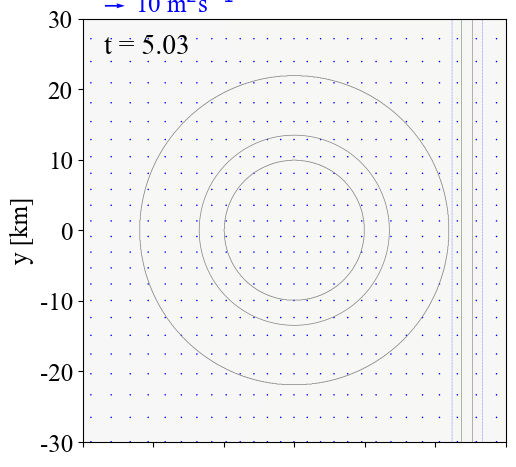

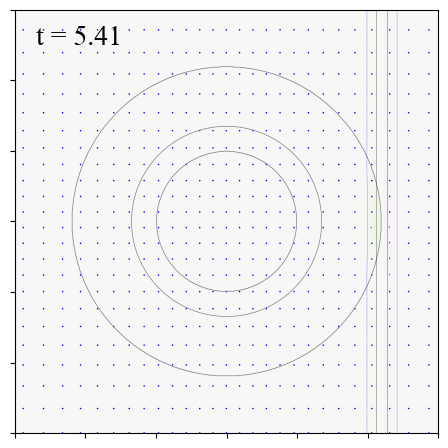

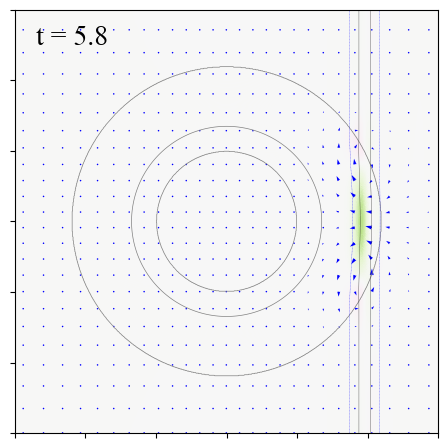

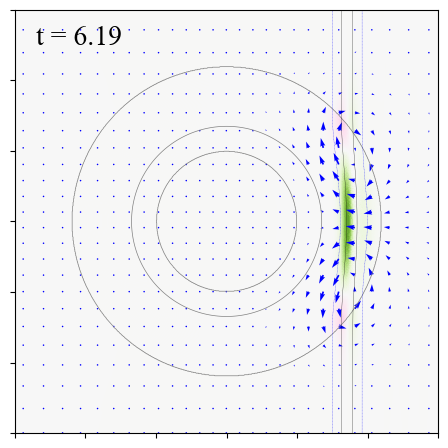

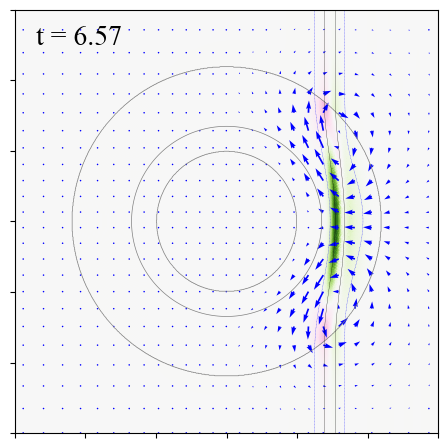

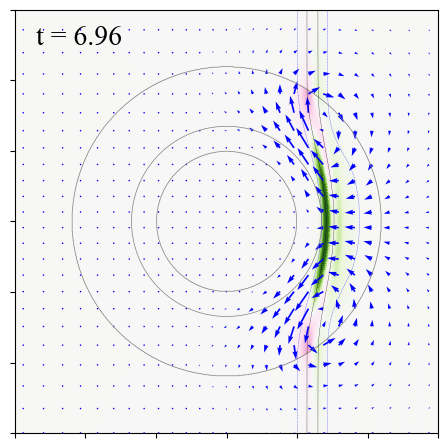

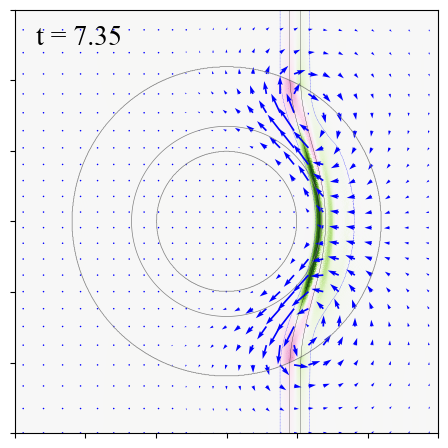

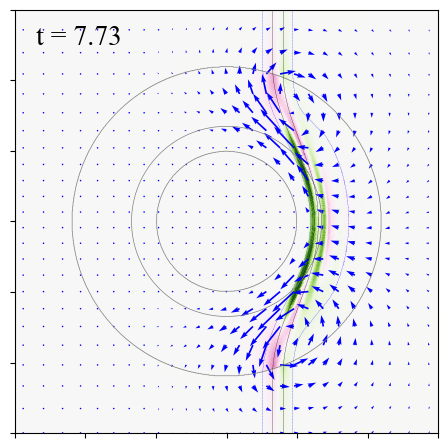

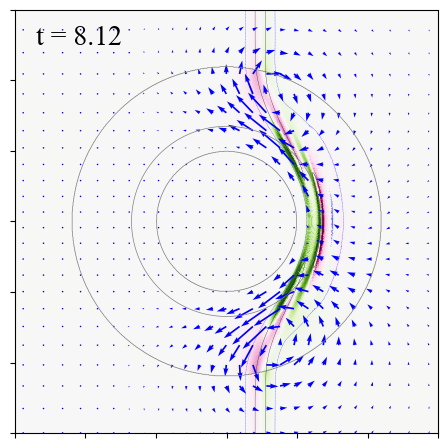

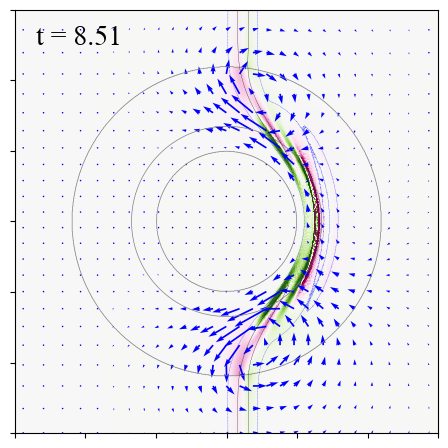

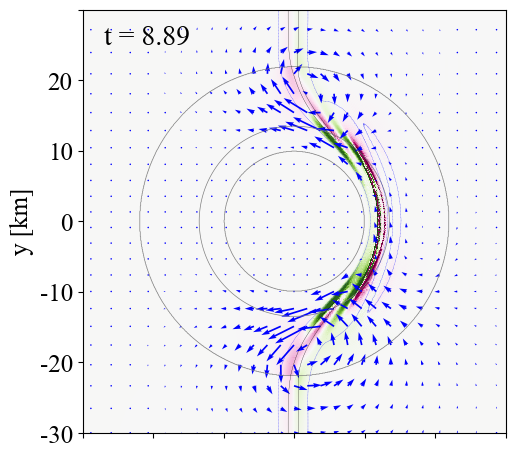

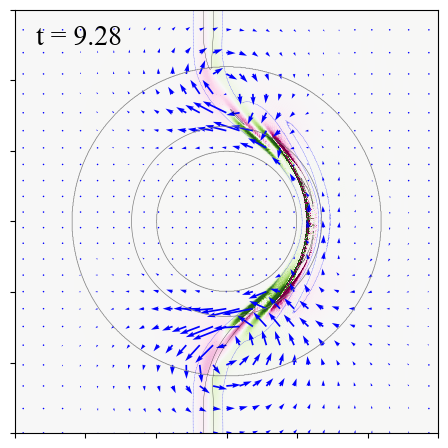

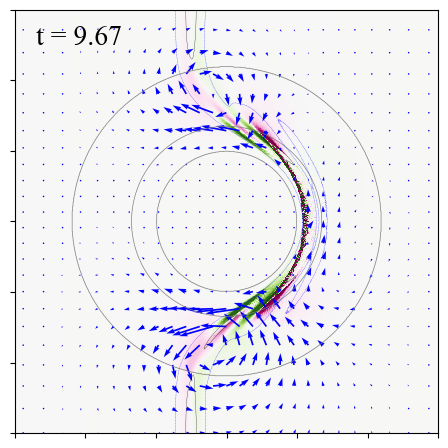

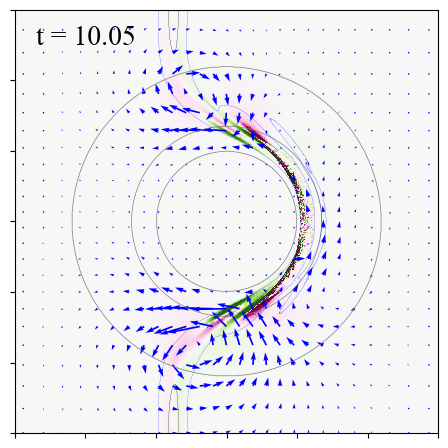

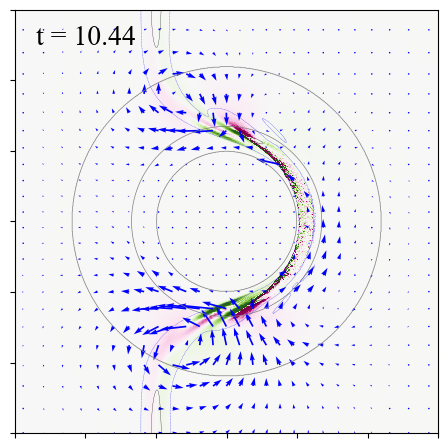

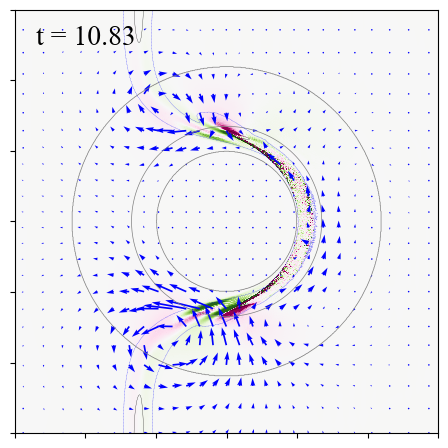

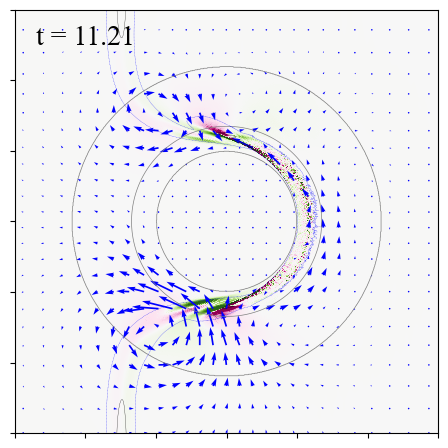

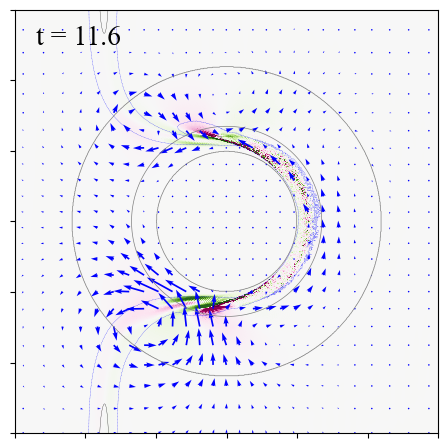

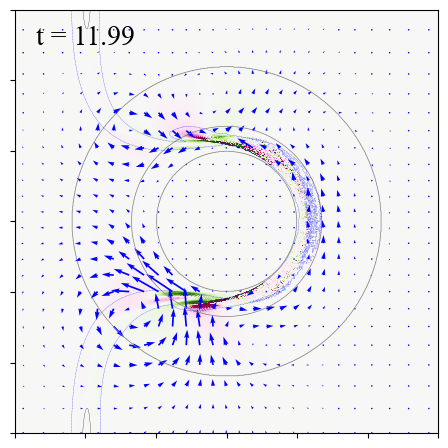

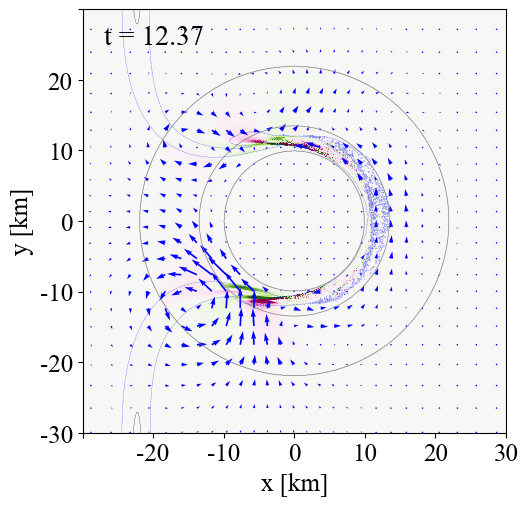

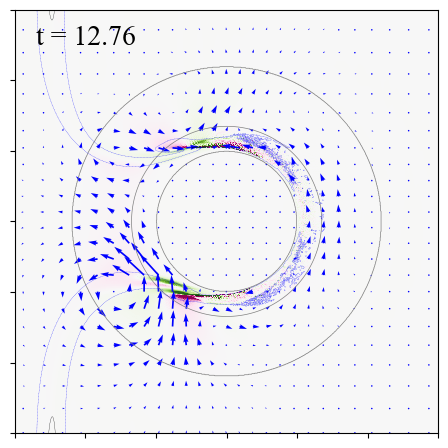

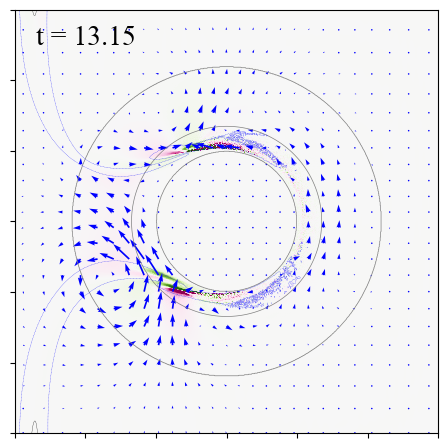

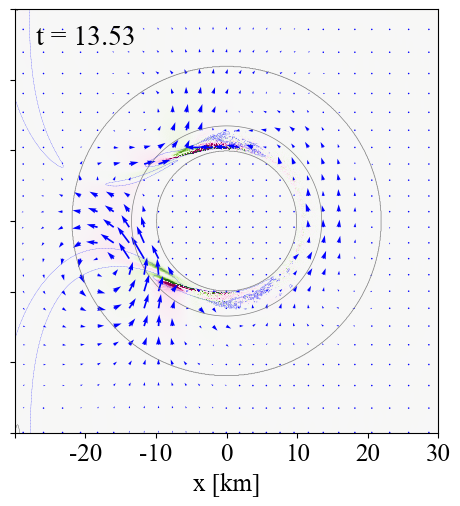

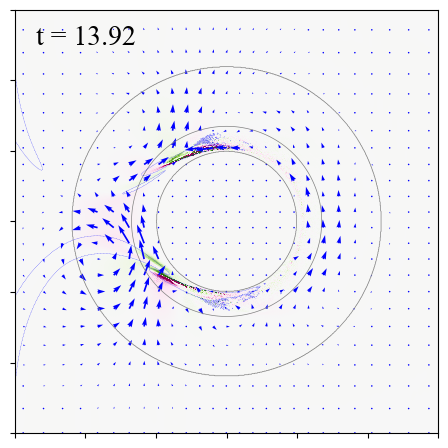

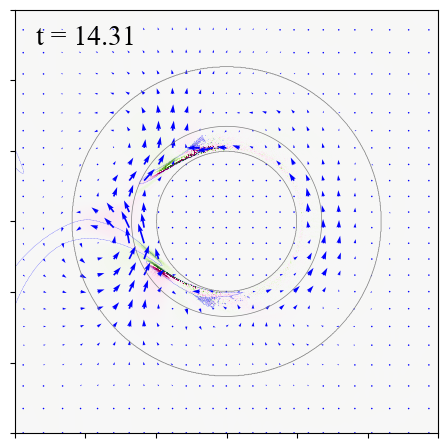

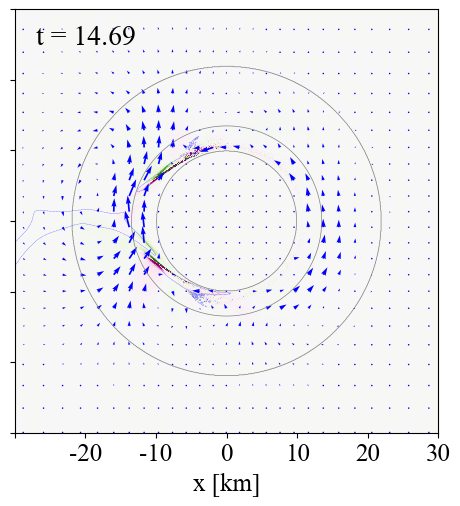

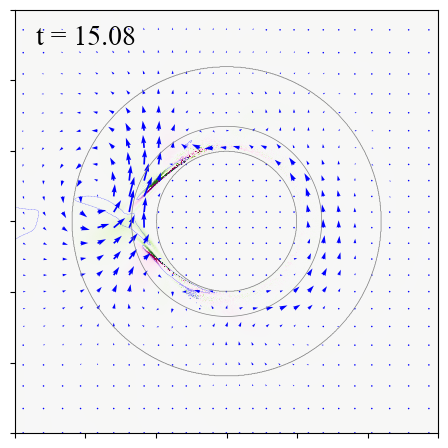

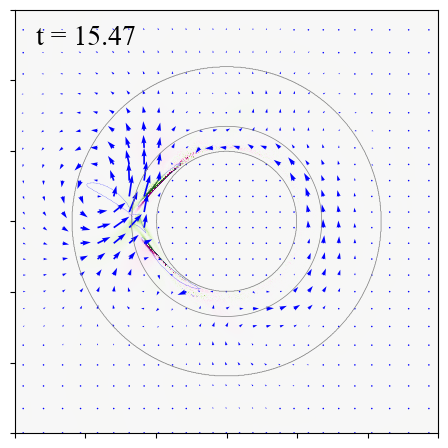

In [16]:
count = 0
for idx_t_data in np.arange(39,120+1,3):
    
    idx_t_ = count+13

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5.5,5.5))
    im1 = (data.C[idx_t_data,:,:]+data_Cadv.Ah0[idx_t_,:,:]).T.plot.pcolormesh(ax=ax, vmax=.5, vmin=-.5, cmap=cm.PiYG_r, add_colorbar=False)
    Q = ax.quiver(data.x.data[::40], data.y.data[::40], (data.U.data[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, (data.V.data[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, scale=.5e2, scale_units='inches', width=4e-3, color='b')
    if idx_t_data == 39: #42:
        qk = ax.quiverkey(Q, 0.1, 1.03, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)
    (data_.dEk_prime[idx_t_data,:,:]+data_.dEp_prime[idx_t_data,:,:]).T.plot.contour(levels=np.array([1e4]), colors='k', linewidths=.2)
    (data_.dEk_prime[idx_t_data,:,:]+data_.dEp_prime[idx_t_data,:,:]).T.plot.contour(levels=np.array([.1e4]), linestyles='dashed', colors='b', linewidths=.2)
    
    ax.set_xlim([x_c-30000, x_c+30000])
    ax.set_ylim([y_c-30000, y_c+30000])
    ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
    ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
    if idx_t_data in [96,105,114]:
        if idx_t_data == 100:
            ax.set_xticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
        else:
            ax.set_xticklabels(['', '-20', '-10', '0', '10', '20', '30'])
        ax.set_xlabel('x [km]', fontsize=18)
    else:
        ax.set_xticklabels('')
        ax.set_xlabel('')
    if idx_t_data in [39,69,96]:    
        if idx_t_data == 39: #42:
            ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
        else:
            ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', ''])
        ax.set_ylabel('y [km]', fontsize=18)
    else:
        ax.set_yticklabels('')
        ax.set_ylabel('')
    ax.set_aspect('equal')
    ax.text(x_c-30000+3000, y_c+25000, f't = {np.round(t_nondim[idx_t_data],2)}', fontsize=20)
    ax.set_title('')
    ax.tick_params(axis='both', which='major', labelsize=18)
    plt.rcParams["font.family"] = "Times New Roman"
    count += 1
        
    plt.savefig(outfilepath+ f"UH_overhead_summer_f_t{idx_t_data}.png", transparent=True, dpi=300)